<a href="https://colab.research.google.com/github/IsaacFigNewton/CommitteeHearingDiscourseParser/blob/main/DH2024_DigitalDemocracy_Demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Accessing & working with the Digital Democracy Corpus: Comprehensive Proceedings of Four State Legislatures 2015-2018


This notebook will act as a guide for a person with minimal knowledge of coding to make use of the files and retrieve useful information from the corpus.


The dataset can be downloaded directly from this website: https://huggingface.co/datasets/iatpp/digitaldemocracy-2015-2018

This corpus is distributed under the cc-by-nc-sa-4.0 license. Please review before accessing. https://creativecommons.org/licenses/by-nc-sa/4.0/

Please cite as:

Khosmood, F., Dekhtyar, A., Ellwein, S., White, B., "The Digital Democracy Corpus: Comprehensive Proceedings of Four State Legislatures 2015-2018", Digital Humanities, Washington, DC, August 2024.

# Download files

The Digital Democracy Corpus can be downloaded from here: https://huggingface.co/datasets/iatpp/digitaldemocracy-2015-2018

The following code cell will downloaded the relevant files from the data repository and store them in the Colab runtime.

 Files in Colab runtime storage can be accessed by clicking on the folder button on the left sidebar. Double click on a file to view a preview of the file. Anything stored Colab runtime storage will disappear once the session is over. To save these files to your physical computer, right click on the file you'd like to save and click download.

In [1]:
from pathlib import Path
import subprocess
import zipfile
import os

#This is where the unzipped corpus file is stored
CORPUS_FILE_PATH = 'DH2024_Corpus_Release/'
corpus_dir = Path(CORPUS_FILE_PATH)
zip_path = Path("digitaldemocracy-2015-2018/DH2024_Corpus_Release.zip")
repo_dir = Path("digitaldemocracy-2015-2018")

# Clone repository if not present
if not repo_dir.is_dir():
    print("Corpus directory not found. Cloning repository...")
    subprocess.run(
        ["git", "clone", "https://huggingface.co/datasets/iatpp/digitaldemocracy-2015-2018"],
        check=True,
    )
    print("Repository cloned successfully.")

# Extract zip file if corpus directory doesn't exist
if not corpus_dir.is_dir():
    if zip_path.exists():
        print(f"Extracting {zip_path}...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall('.')
        print("Extraction complete.")
    else:
        print(f"Error: {zip_path} not found!")
else:
    print(f"Corpus already extracted at {corpus_dir}")

Corpus already extracted at DH2024_Corpus_Release


# Import and config

In [2]:
from src import HearingLoader, HearingTagger, HearingParser

text_features = [HearingParser.TEXT_COL]
categorical_features = HearingParser.CAT_COLS
numeric_features = HearingParser.NUM_COLS

# Initialize the HearingLoader with the corpus path
loader = HearingLoader(corpus_path='DH2024_Corpus_Release/')
tagger = HearingTagger()
parser = HearingParser()

# Discussion Transcripts

In [3]:
# discussion will contain all the information from bill CA_201720180AB10 in hearing id 51835
# 'CA_201720180AB10': ['51835',
#   '52298',
#   '52708',
#   '52856',
#   '53960',
#   '54363',
#   '54505']
hearing = loader.bill_discussion_info(51835, "CA_201720180AB10")
# vars(hearing)

In [4]:
# Using pprint_hearing we layout the transcript in a human readable format
HearingLoader.pprint_hearing(hearing)


State:		CA
Committee:	Assembly Standing Committee on Education
Bill:		CA_201720180AB10
Date:		2017-03-15

Transcript:
Patrick O'Donnell:   She'll be presenting AB 10, file item number one.
Cristina Garcia:     Thank you. Good afternoon Chair and members. I'm here presenting AB 10 would require vital menstrual products, pads, and tampons to be provided in school, colleges, shelters throughout the state. Menstrual products are a basic necessity similar to toilet paper. As early as the fourth grade young girls get their period and may not be prepared nor understand the natural changes of their bodies many of these young girls end up missing school three to five days a month on a regular basis, because they lack basic access to these products. No young girl should ever have to miss school because she does not have access to these basic health needs. For some young girls, access to these products is an additional barrier to their education. It's also loss of funding for school due to absen

# Try loading all the hearings

In [5]:
hearings = loader.load_all_committee_hearings()
relevant_hearings = [h for h in hearings if h.bid != 'CA_NO BILL DISCUSSED']

invalid literal for int() with base 10: 'hid'
invalid literal for int() with base 10: 'hid'
invalid literal for int() with base 10: 'hid'


In [6]:
print(len(hearings))
print(len(relevant_hearings))

8218
7069


In [7]:
relevant_hearings = [tagger(h) for h in relevant_hearings]

In [8]:
utterances_df = parser._build_utterance_rows(relevant_hearings)

In [9]:
utterances_df.head(500).to_csv('utterances_sample.csv')

In [10]:
import pandas as pd

labeled_utterances_df = pd.read_csv('./utterances_sample_labeled.csv')

In [11]:
labeled_utterances_df.head()

,Unnamed: 0,hid,bid,state,uid,pid,text,prev_text,next_text,context_text,...,word_count,bids_mentioned,has_bill_action,has_presentation_cue,has_motion_cue,has_vote_cue,has_disposition_cue,aye_count,no_count,stage_label
0,0,52054,CA_201720180AB92,CA,0,165448,"Welcome, Mr. Bonta.",NaN,"Thank you, I feel welcome.","PREV: CURR: Welcome, Mr. Bonta. NEXT: Thank y...",...,3,0,0,0,0,0,0,0,0,PRESENTATION
1,1,52054,CA_201720180AB92,CA,1,85,"Thank you, I feel welcome.","Welcome, Mr. Bonta.","And I know you were here earlier, and we appre...","PREV: Welcome, Mr. Bonta. CURR: Thank you, I f...",...,5,0,0,0,0,0,0,0,0,PRESENTATION
2,2,52054,CA_201720180AB92,CA,2,165448,"And I know you were here earlier, and we appre...","Thank you, I feel welcome.",Thank you for encouraging them. Good to see yo...,"PREV: Thank you, I feel welcome. CURR: And I k...",...,18,0,0,0,0,0,0,0,0,PRESENTATION
3,3,52054,CA_201720180AB92,CA,3,85,Thank you for encouraging them. Good to see yo...,"And I know you were here earlier, and we appre...","Thank you very much, if witnesses would like t...","PREV: And I know you were here earlier, and we...",...,110,1,0,0,0,1,0,1,1,VOTE
4,4,52054,CA_201720180AB92,CA,4,165448,"Thank you very much, if witnesses would like t...",Thank you for encouraging them. Good to see yo...,"Madam Chair, members. Eddie Bernacchi, on beha...",PREV: Thank you for encouraging them. Good to ...,...,15,0,0,0,0,0,0,0,0,PUBLIC_COMMENTS


In [12]:
labeled_utterances_df['stage_label'].value_counts()

stage_label
PRESENTATION             192
PUBLIC_COMMENTS          168
VOTE                      69
LEGISLATOR_DISCUSSION     35
INTRO                     18
CLOSING_REMARKS           18
Name: count, dtype: int64

In [13]:
for col in text_features:
  labeled_utterances_df[col] = labeled_utterances_df[col].fillna('')

labeled_utterances_df['stage_label'] = labeled_utterances_df['stage_label'].fillna('unknown')
labeled_utterances_df["speaker_position"] = labeled_utterances_df["speaker_position"]/labeled_utterances_df["speaker_position"].max()

# Evaluation

In [14]:
from sklearn.model_selection import GroupShuffleSplit

groups = labeled_utterances_df['bid']

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.25,
    random_state=42,
)

train_idx, test_idx = next(
    splitter.split(labeled_utterances_df, labeled_utterances_df['stage_label'], groups)
)

train_df = labeled_utterances_df.iloc[train_idx].copy()
test_df = labeled_utterances_df.iloc[test_idx].copy()

print('Train rows:', len(train_df))
print('Test rows:', len(test_df))

Train rows: 310
Test rows: 190


In [15]:
for col in numeric_features:
  labeled_utterances_df[col] = labeled_utterances_df[col].fillna(0)
  train_df[col] = train_df[col].fillna(0)
  test_df[col] = test_df[col].fillna(0)

for col in categorical_features:
  labeled_utterances_df[col] = labeled_utterances_df[col].fillna('unknown')
  train_df[col] = train_df[col].fillna('unknown')
  test_df[col] = test_df[col].fillna('unknown')

In [16]:
# Prepare train and test data
feature_cols = text_features + categorical_features + numeric_features

X_train = train_df[feature_cols]
y_train = train_df['stage_label']

X_test = test_df[feature_cols]
y_test = test_df['stage_label']

# Train the model using HearingParser's train_model method
parser.train_model(train_df, label_col='stage_label')

# The model is now accessible via parser.model

In [17]:
from sklearn.metrics import classification_report

# Use the parser's model for prediction
pred = parser.model.predict(X_test)

print(classification_report(
    y_test,
    pred,
    digits=3,
))

                       precision    recall  f1-score   support

      CLOSING_REMARKS      0.667     1.000     0.800         6
                INTRO      0.444     0.667     0.533         6
LEGISLATOR_DISCUSSION      0.636     0.636     0.636        11
         PRESENTATION      0.879     0.829     0.853        70
      PUBLIC_COMMENTS      0.865     0.831     0.848        77
                 VOTE      0.952     1.000     0.976        20

             accuracy                          0.837       190
            macro avg      0.741     0.827     0.774       190
         weighted avg      0.846     0.837     0.839       190



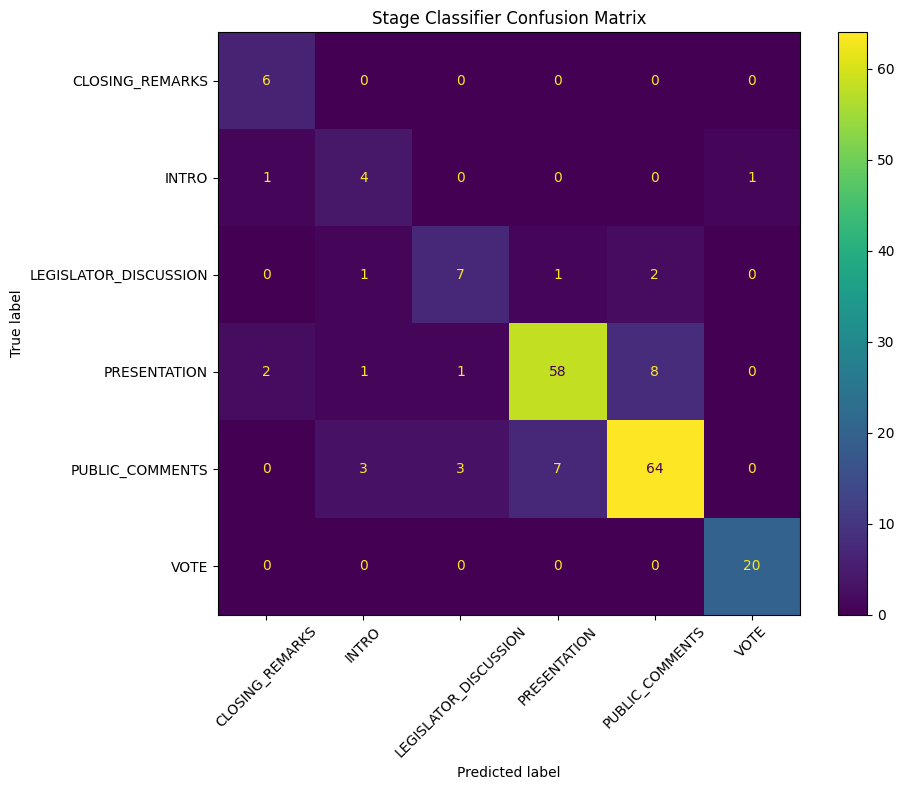

In [18]:
import matplotlib.pyplot as plt

from sklearn.metrics import ConfusionMatrixDisplay


labels = sorted(y_test.unique())

fig, ax = plt.subplots(figsize=(10, 8))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred,
    labels=labels,
    xticks_rotation=45,
    ax=ax,
)

ax.set_title('Stage Classifier Confusion Matrix')
plt.tight_layout()
plt.show()

In [19]:
# Removed standalone functions - now using HearingParser methods:
# - parser.smooth_label_list() for label smoothing
# - parser.predict_hearing_sections() for single hearing prediction
# - parser.predict_hearings_batch() for batch prediction

In [20]:
# Use the parser's predict_hearing_sections method
labels = parser.predict_hearing_sections(
    hearing=relevant_hearings[0],
    utterances_df=utterances_df,
    smooth=True,
)

print(labels)

['CLOSING_REMARKS', 'CLOSING_REMARKS', 'CLOSING_REMARKS', 'CLOSING_REMARKS', 'CLOSING_REMARKS', 'PUBLIC_COMMENTS', 'PUBLIC_COMMENTS', 'PUBLIC_COMMENTS', 'CLOSING_REMARKS', 'CLOSING_REMARKS', 'CLOSING_REMARKS', 'VOTE', 'VOTE', 'PUBLIC_COMMENTS', 'PUBLIC_COMMENTS', 'CLOSING_REMARKS', 'CLOSING_REMARKS', 'CLOSING_REMARKS']


In [21]:
special_hearing = None
for h in relevant_hearings:
  if h.bid == 'CA_201720180AB2721':
    special_hearing = h
    break

In [22]:
standard_example = relevant_hearings[0]

Note: special case of Chairman presenting to someone else: Bill ID CA_201720180SB1293

Special kind of bill discussion: CA_201720180AB1708
Case where you have to use handoff cue: CA_201720180AB2721
CA_201720180SCR159

In [23]:
def pprint_hearing_labels(hearing, parser, utterances_df):
  """Print formatted transcript with predicted section labels.
  
  Args:
      hearing: The hearing to print
      parser: HearingParser instance with trained model
      utterances_df: DataFrame with utterance features
  """
  labels = parser.predict_hearing_sections(
    hearing=hearing,
    utterances_df=utterances_df,
    smooth=True,
  )

  print()
  print(f"State:\t\t{hearing.state}")
  print(f"Committee:\t{hearing.cname}")
  print(f"Bill:\t\t{hearing.bid}")
  print(f"Date:\t\t{hearing.hearing_date.strftime('%Y-%m-%d')}")
  print()
  print("Transcript:")
  for i, contribution in enumerate(hearing.utterances):
    speaker = hearing.speakers[contribution.pid]
    print(f'[{labels[i] if i < len(labels) else "UNKNOWN"}]')
    first_name = speaker.first_name or "UNKNOWN"
    last_name = speaker.last_name or "UNKNOWN"
    name = f"{first_name} {last_name}:"
    print(f"{name:<20} {contribution.text}")
  print()

# Sanity Checks

In [24]:
standard_example_2 = relevant_hearings[17]

In [25]:
HearingLoader.pprint_hearing(standard_example)


State:		CA
Committee:	Assembly Standing Committee on Accountability and Administrative Review
Bill:		CA_201720180AB92
Date:		2017-03-22

Transcript:
Susan Eggman:        welcome mr bonta
Rob Bonta:           thank you i feel welcome
Susan Eggman:        and i know you were here earlier and we appreciate your getting your steps in by coming back
Rob Bonta:           thank you for encouraging them good to see you good morning i know in the last bill here i m very pleased to have the opportunity to present ab 92 thank you ab 92 will extend the sunset clause on the current 5 retention cap statute pertaining to public works projects from january 1 2018 to january 1 2023 this is a vital policy for the construction industry especially for small and emerging construction businesses i think you have seen this policy before it s worked well in action and i think it deserves a five year additional extension and there s no opposition respectfully ask for your aye vote
Susan Eggman:        thank y

In [26]:
pprint_hearing_labels(standard_example, parser, utterances_df)


State:		CA
Committee:	Assembly Standing Committee on Accountability and Administrative Review
Bill:		CA_201720180AB92
Date:		2017-03-22

Transcript:
[CLOSING_REMARKS]
Susan Eggman:        welcome mr bonta
[CLOSING_REMARKS]
Rob Bonta:           thank you i feel welcome
[CLOSING_REMARKS]
Susan Eggman:        and i know you were here earlier and we appreciate your getting your steps in by coming back
[CLOSING_REMARKS]
Rob Bonta:           thank you for encouraging them good to see you good morning i know in the last bill here i m very pleased to have the opportunity to present ab 92 thank you ab 92 will extend the sunset clause on the current 5 retention cap statute pertaining to public works projects from january 1 2018 to january 1 2023 this is a vital policy for the construction industry especially for small and emerging construction businesses i think you have seen this policy before it s worked well in action and i think it deserves a five year additional extension and there s no op

In [27]:
len(relevant_hearings[1].utterances)

33

In [28]:
tagger._detect_first_presentation_utterance(relevant_hearings[9])

19

In [29]:
relevant_hearings[4].bid

'CA_201720180AB677'